The objective of part 4 is to test the scale invariance of $\Delta B _s$ at different s (scale) values, by plotting the different normalized pdf followed by the sample at varying $s$ values

Get the data:

In [136]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sp

filename='Y1.txt'
data = pd.read_csv(filename).to_numpy()
B = np.cumsum(data)
s_values = 2**np.array([3,4,5,6,7,8,9])
deltaB = [] # empty list, to be filled with s values
df = pd.DataFrame()

def poly_fit(x, y, order=3):
    # revert order of coeffs from x^0 to x^3
    coeff = np.polyfit(x, y, order)
    p = np.poly1d(coeff)
    return p(x)

def get_deviation(y, s):
    #preparo array deviations
    deviations = np.zeros(len(y))

    x = np.arange(len(y))
    segment_length = 2*s
    # numero di segmenti su cui fare sliding
    
    for k in range(0, len(y), segment_length):
        # prendo un segmento e faccio fit
        x_slice = x[k:k+segment_length]
        y_slice = y[k:k+segment_length]
        y_fitted = poly_fit(x_slice, y_slice, order=3)
        #plt.plot(x_slice, y_slice)
        #plt.plot(x_slice, y_fitted)
        dev = y_slice-y_fitted
        
        deviations[k:k+segment_length] = dev
    return deviations
for s in s_values:
    z = get_deviation(B, s)
    deltaB.append(z)

    df[s] = z

C:\Users\lcdit\AppData\Local\Temp\ipykernel_13936\450763494.py:15: RankWarning: Polyfit may be poorly conditioned
  coeff = np.polyfit(x, y, order)
C:\Users\lcdit\AppData\Local\Temp\ipykernel_13936\450763494.py:15: RankWarning: Polyfit may be poorly conditioned
  coeff = np.polyfit(x, y, order)
C:\Users\lcdit\AppData\Local\Temp\ipykernel_13936\450763494.py:15: RankWarning: Polyfit may be poorly conditioned
  coeff = np.polyfit(x, y, order)
C:\Users\lcdit\AppData\Local\Temp\ipykernel_13936\450763494.py:15: RankWarning: Polyfit may be poorly conditioned
  coeff = np.polyfit(x, y, order)
C:\Users\lcdit\AppData\Local\Temp\ipykernel_13936\450763494.py:15: RankWarning: Polyfit may be poorly conditioned
  coeff = np.polyfit(x, y, order)
C:\Users\lcdit\AppData\Local\Temp\ipykernel_13936\450763494.py:15: RankWarning: Polyfit may be poorly conditioned
  coeff = np.polyfit(x, y, order)


## Testing the scale invariance of the process:

To test the scale invariance of  $\Delta B _s$, we started by normalizing the pdfs obtained from the dataset at different $s$ values.


After having obtained $\Delta B _s(i) = B^*(i+s)- B^*(i)$ , we calculated $\sigma_s$ for each dataset, and we computed the pdfs of $\Delta B _s$ from the histogram over their distribution. To normalize these distribution and check the scale invariance, we did the variable change 

$\Delta B _s \rightarrow \Delta B _s/\sigma_s$

and having to maintain the integral to one,

$y = P ( \Delta B _s ) \rightarrow y' = P ( \Delta B _s ) \cdot \sigma_s $

, since

$
\int^{+\infty}_{-\infty}P(\Delta B_s)\ dB_s = 1 = \int^{+\infty}_{-\infty} ( P(\Delta B_s)\cdot \sigma_s )\  dB_s/\sigma_s
$




Il codice qui sotto è stato incluso nella parte successiva, con anche il fit alla castaign function

In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def normalize_ds(data):
    sigma = data.std()
    nbins = int(np.sqrt(len(data)))
    pdf, bin_edges = np.histogram(data, bins=nbins, density=True)
    

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    x = bin_centers / sigma
    y =  pdf * sigma
    return(x,y)


def plot_collapse(increments_df):
    """
    increments_df è un dataframe dove le colonne sono i diversi valori di s
    """
    plt.figure(figsize=(10, 6))
    
    def plot_single_column(col):
        s = col.name
       
        # Rimozione eventuali NaN (non dovrebbero essercene)
        data = col.dropna()

        x,y = normalize_ds(data)
        # Plot diretto
        plt.semilogy( x , y , ls='', marker = 'o',label=f's={s}',ms = 3)

    # Applichiamo la funzione a ogni colonna (axis=0 è il default)
    increments_df.apply(plot_single_column)

    plt.title('Data Collapse: Rescaled PDFs')
    plt.xlabel(r'$\Delta_s B / \sigma_s$')
    plt.ylabel(r'$\sigma_s \cdot P(\Delta_s B)$')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.show()

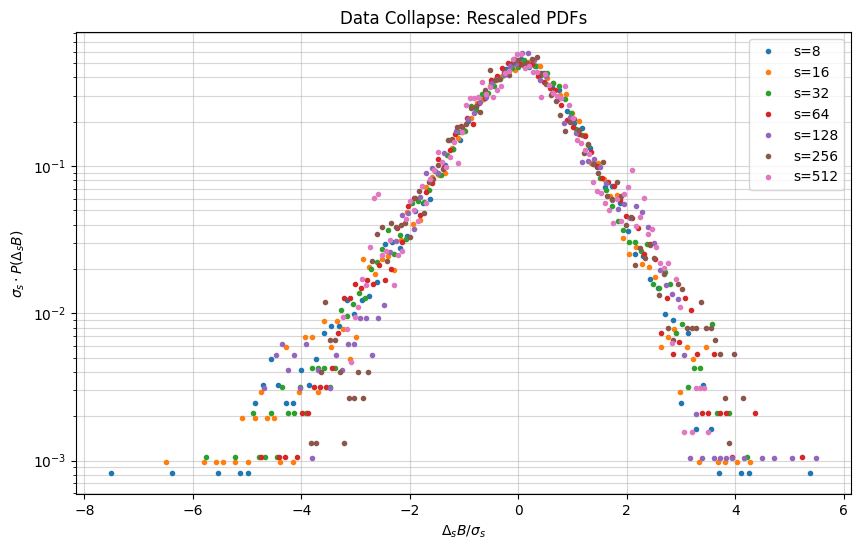

In [138]:
plot_collapse(df)

## Non-Gaussian fit: The Castign's equation

In order to obtain an appropriate fit for the fat tails observed in the dataset, we tried fitting with the Castign's equation:

$\tilde{P_s}(x) = \int P_L(x/\sigma)\frac{1}{\sigma}G_{s,L}(ln\sigma)d(ln\sigma)$

In this method, the PDF at scale s, \tilde{P_s}(x), is considered as a mixture of gaussian with different $\sigma$ values. In particular:

- $ P_L(x/\sigma)\frac{1}{\sigma}$ is a standard gaussian, the limit distribution of the increments.
- $G_{s,L}(ln\sigma)$ is the distribution of the standard deviations, assuming it i s a gaussian in $ln\sigma$ ($\sigma$ Log-Normal) as in the paper.

Since the fitted pdf is standardized, $E[\sigma^2]=1$ (1), defining $\xi = ln\sigma$ and assuming  $\xi\sim N(\mu,\lambda^2)$, from (1) we get $\mu = -\lambda^2$. 

So, we only have a free parameter $\lambda^2$, and $G_{s,L}$ assumes the form:

$G_{s,L}(ln\sigma) = \frac{1}{\sqrt{2\pi}\lambda}\text{exp}\big(-\frac{(ln\sigma+\lambda^2)^2}{2\lambda^2}\big)$

In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import curve_fit


def castaing_integrand(ln_sigma, x, lambda2):

    mu = -lambda2 
    sigma_val = np.exp(ln_sigma)
    
    # P_L: Gaussiana standard (media 0, dev std 1)
    p_l = (1 / (np.sqrt(2 * np.pi) * sigma_val)) * np.exp(-0.5 * (x / sigma_val)**2)
    
    # G: Kernel Gaussiano per ln(sigma) con varianza lambda2
    g_kernel = (1 / (np.sqrt(2 * np.pi * lambda2))) * np.exp(-0.5 * (ln_sigma - mu)**2 / lambda2)
    
    return p_l * g_kernel

def castaing_pdf(x, lambda2): 
    # Questa funzione deve gestire x sia come scalare che come array per curve_fit
    # Se x è un array numpy, iteriamo.
    if np.isscalar(x):
        x = np.array([x])
        
    y_vals = []
    # Limiti di integrazione ± 4 sigma del kernel log-normale
    limit = 4 * np.sqrt(lambda2) 
    mu = -lambda2
    
    for val in x:
        
        res, _ = quad(castaing_integrand, mu - limit, mu + limit, args=(val, lambda2))
        y_vals.append(res)
            
    return np.array(y_vals)

def normalize_ds(data):
    sigma = data.std()
    nbins = int(np.sqrt(len(data)))
    pdf, bin_edges = np.histogram(data, bins=nbins, density=True)
    

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    x = bin_centers / sigma
    y =  pdf * sigma
    return(x,y)

def get_res(df):
    # Dizionari per salvare i risultati
    results = {} # bin_centers e pdf per ogni s
    lambdas = [] # valori di lambda2
    lambda_errors = [] # errori

    for s in df.columns:

        data_s = df[s].dropna().values

        # PDF sperimentale
        bin_centers, pdf = normalize_ds(data_s)
        
        # Parametri iniziali e bounds
        p0 = [0.1]
        bounds = (0.001, 2.0)
        
        try:
            # fit
            popt, pcov = curve_fit(castaing_pdf, bin_centers, pdf, p0=p0, bounds=bounds)
            
            l2 = popt[0]
            l2_err = np.sqrt(np.diag(pcov))[0]
            
            # Salvataggio risultati
            lambdas.append(l2)
            lambda_errors.append(l2_err)
            results[s] = (bin_centers, pdf)
            
            print(f"Scale s={s}: Lambda^2 = {l2:.3f} +/- {l2_err:.3f}")
            
        except Exception as e:
            print(f"Fitting error for scale {s}: {e}")
    return(results,lambdas,lambda_errors)

def plot_results(results, lambdas, lambda_errors, show_collapse=True, show_lambda=True):
    """
    Plotta i risultati dell'analisi di invarianza di scala.
    
    Args:
        results: Dizionario con i dati per ogni scala.
        lambdas: Lista dei valori lambda^2.
        lambda_errors: Lista degli errori su lambda^2.
        show_collapse (bool): Se True, mostra il Collapse Plot (sinistra).
        show_lambda (bool): Se True, mostra il grafico Lambda vs Log(s) (destra).
    """
    
    # Media Pesata
    weights = 1 / np.array(lambda_errors)**2
    lambda_mean = np.average(lambdas, weights=weights)
    err_mean = 1 / np.sqrt(np.sum(weights))

    print(f"W. Mean Lambda^2 +/- err: {lambda_mean:.4f} +/- {err_mean:.4f}")

    # Se non è richiesto nessun plot, esci
    if not show_collapse and not show_lambda:
        return

    # 2. Configurazione dinamica della figura
    if show_collapse and show_lambda:
        fig, (ax1, ax2) = plt.subplots(figsize=(16, 6), nrows=1, ncols=2)
    elif show_collapse:
        fig, ax1 = plt.subplots(figsize=(8, 6))
        ax2 = None
    elif show_lambda:
        fig, ax2 = plt.subplots(figsize=(8, 6))
        ax1 = None

    # A: Collapse Plot (Scale Invariance)
    if show_collapse and ax1 is not None:
        colors = plt.colormaps['viridis'](np.linspace(0, 1, len(results)))

        for i, s in enumerate(results):
            bc, p = results[s]
            ax1.semilogy(bc, p, 'o', markersize=3, alpha=0.5, color=colors[i], label=f's={s}')

        # Curva teorica
        x_theory = np.linspace(-5, 5, 100)
        y_theory = castaing_pdf(x_theory, lambda_mean)
        
        ax1.semilogy(x_theory, y_theory, 'r-', linewidth=2.5, label=rf'Global Fit $\lambda^2={lambda_mean:.2f}$')
        ax1.set_title('Collapse Plot: Critical Scale Invariance')
        ax1.set_xlabel(r'$\Delta_s B / \sigma$')
        ax1.set_ylabel(r'$\sigma_s \cdot P(\Delta_s B)$')
        ax1.set_ylim(5*1e-4, 2)
        
        
        if len(results) > 10:
            # Mostra solo fit globale nella legenda se ci sono troppe voci
            handles, labels = ax1.get_legend_handles_labels()
            ax1.legend([handles[-1]], [labels[-1]], loc='best')
        else:
            ax1.legend(loc='best', fontsize='small')
            
        ax1.grid(True, which="both", ls="-", alpha=0.3)

    # B: Lambda vs Log(s)
    if show_lambda and ax2 is not None:
        s_values = list(results)
        
        ax2.errorbar(s_values, lambdas, yerr=lambda_errors, fmt='ko', ls='--', capsize=3, label=r"$\lambda^2$ values")
        
        ax2.hlines(lambda_mean, min(s_values)/1.5, max(s_values)*1.5, colors='red', linestyles='-', label=r"Weighted Mean $\lambda^2$")
        
        ax2.fill_between([min(s_values)/1.5, max(s_values)*1.5], 
                         lambda_mean - err_mean, lambda_mean + err_mean, 
                         color='red', alpha=0.1, label=r"Mean Uncertainty ($1\sigma$)")

        ax2.set_xscale('log')
        ax2.grid(True, which="both", ls="-", alpha=0.3)
        ax2.set_xlabel(r"log(s)")
        ax2.set_ylabel(r"$\lambda^2$")
        ax2.set_title(rf"Dependence of $\lambda^2$ on Scale $s$")
        ax2.set_xlim(min(s_values)/1.5, max(s_values)*1.5)
        ax2.legend(loc='best')

    plt.tight_layout()
    plt.show()


def lambda_comp(lambdas,lambda_errors,s):
    '''
        Valuta la compatibilità dei lambda^2 ottenuti con una retta a pendenza nulla
    '''
    def line(x,m,b):
        return(m*x+b)
    popt,pcov = curve_fit(line,np.log(s),lambdas,[0,0.16],lambda_errors)
    m = popt[0]
    dm = np.sqrt(np.diag(pcov))[0]
    print(f"Fitting a line to Lambda^2, we get y=m log(s)+b with:\nm +/- dm = {m:.3f} +/- {dm:.3f}")


Scale s=8: Lambda^2 = 0.168 +/- 0.007
Scale s=16: Lambda^2 = 0.136 +/- 0.010
Scale s=32: Lambda^2 = 0.138 +/- 0.009
Scale s=64: Lambda^2 = 0.174 +/- 0.006
Scale s=128: Lambda^2 = 0.200 +/- 0.011
Scale s=256: Lambda^2 = 0.171 +/- 0.012
Scale s=512: Lambda^2 = 0.141 +/- 0.016
W. Mean Lambda^2 +/- err: 0.1640 +/- 0.0034


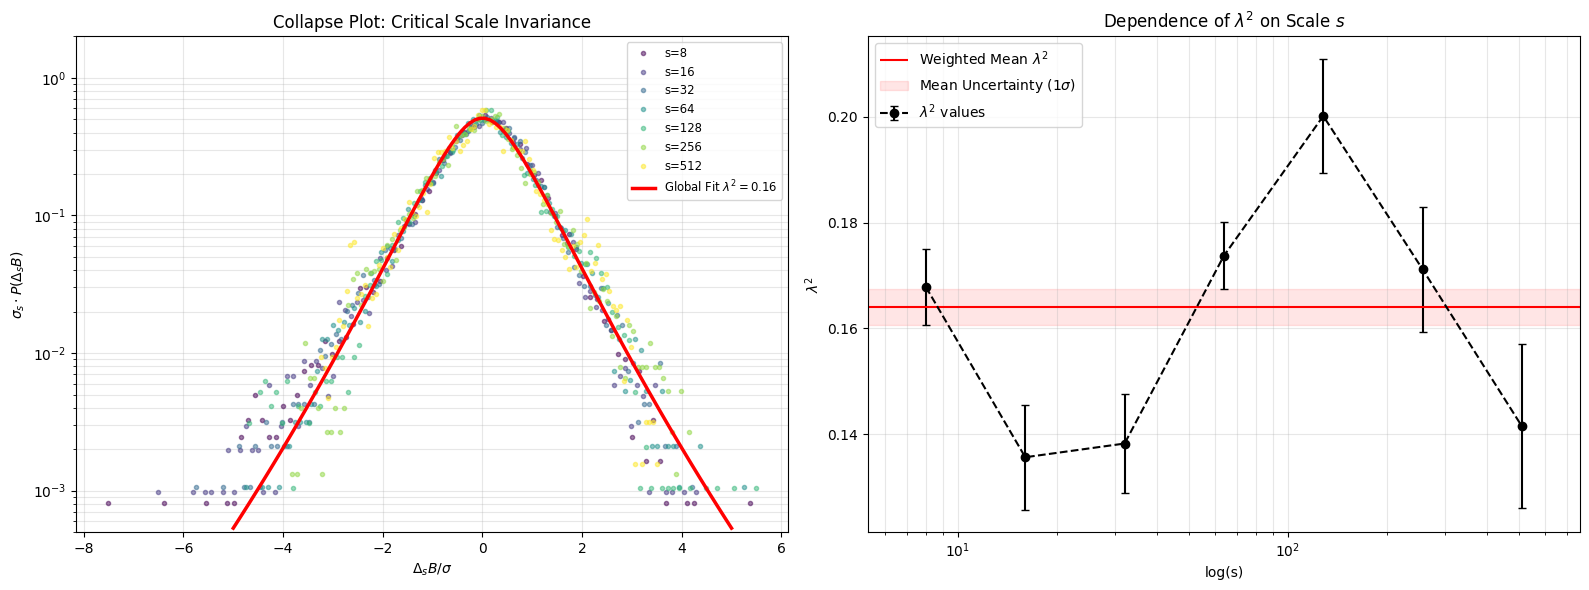

In [150]:
results,lambdas,lambda_errors = get_res(df)
plot_results(results,lambdas,lambda_errors)

In [ ]:
lambda_comp(lambdas,lambda_errors,list(results))

Fitting a line to Lambda^2, we get y=m log(s)+b with:
m +/- dm = 0.004 +/- 0.007
